<a href="https://colab.research.google.com/github/nisha-s10/Pattern-Recognition-Lab-AFI504/blob/main/Experiment%204/Experiment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1 — Import Libraries

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

### Step 2 — Load Dataset and Convert to Binary
The diabetes dataset is continuous, so we create binary labels.

In [50]:
data = load_diabetes()

X = data.data
y = data.target

# Convert to binary classes
y_binary = (y > np.median(y)).astype(int)

print("Dataset shape:", X.shape)
print("Classes:", np.unique(y_binary))

Dataset shape: (442, 10)
Classes: [0 1]


### Step 3 — Standardize Features

In [51]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

### Step 4 — Train/Test Split


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary,
    test_size=0.3,
    random_state=42
)

### Step 5 — Estimate Gaussian Parameters (MLE)

In [53]:
classes = np.unique(y_train)

means = {}
variances = {}
priors = {}

for c in classes:
    X_c = X_train[y_train == c]

    means[c] = np.mean(X_c, axis=0)
    variances[c] = np.var(X_c, axis=0) + 1e-6
    priors[c] = len(X_c) / len(X_train)

### Step 6 — Gaussian Likelihood Function

In [54]:
def gaussian_pdf(x, mean, var):

    numerator = np.exp(
        -(x - mean)**2 / (2 * var)
    )

    denominator = np.sqrt(
        2 * np.pi * var
    )

    return numerator / denominator

### Step 7 — Likelihood Ratio Test

In [55]:
def log_likelihood_ratio(x):

    log_likelihood_0 = np.sum(
        np.log(
            gaussian_pdf(
                x,
                means[0],
                variances[0]
            )
        )
    )

    log_likelihood_1 = np.sum(
        np.log(
            gaussian_pdf(
                x,
                means[1],
                variances[1]
            )
        )
    )

    return log_likelihood_1 - log_likelihood_0

### Step 8 — Compute Scores

In [56]:
scores = []

for x in X_test:
    scores.append(
    log_likelihood_ratio(x)
  )

scores = np.array(scores)

### Score Distribution Visualization

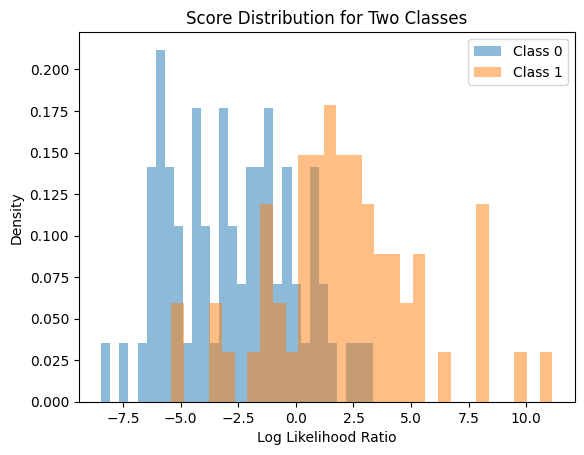

In [57]:
plt.figure()

plt.hist(
    scores[y_test == 0],
    bins=30,
    alpha=0.5,
    density=True,
    label="Class 0"
)

plt.hist(
    scores[y_test == 1],
    bins=30,
    alpha=0.5,
    density=True,
    label="Class 1"
)

plt.xlabel("Log Likelihood Ratio")

plt.ylabel("Density")

plt.title("Score Distribution for Two Classes")

plt.legend()

plt.show()

### Step 9 — ROC Curve Calculation (From Scratch)

In [58]:
thresholds = np.linspace(
    scores.min(),
    scores.max(),
    100
)

TPR = []
FPR = []

for t in thresholds:

    predictions = (
        scores > t
    ).astype(int)

    TP = np.sum(
        (predictions == 1)
        & (y_test == 1)
    )

    FP = np.sum(
        (predictions == 1)
        & (y_test == 0)
    )

    TN = np.sum(
        (predictions == 0)
        & (y_test == 0)
    )

    FN = np.sum(
        (predictions == 0)
        & (y_test == 1)
    )

    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN)

    TPR.append(tpr)
    FPR.append(fpr)

# Find best threshold
TPR = np.array(TPR)
FPR = np.array(FPR)

best_index = np.argmax(TPR - FPR)

best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

Best Threshold: 0.2541105192156383


### Confusion Matrix Visualization

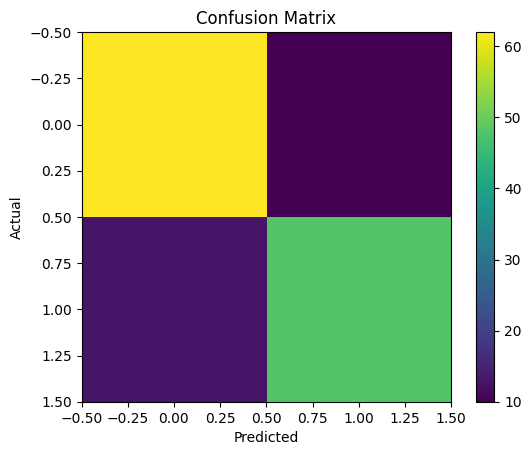

Accuracy: 0.8270676691729323
Sensitivity (TPR): 0.7868852459016393
Specificity (TNR): 0.8611111111111112
Precision: 0.8275862068965517
F1 Score: 0.8067226890756303


In [59]:
predictions = (scores > best_threshold).astype(int)

TP = np.sum((predictions == 1) & (y_test == 1))
FP = np.sum((predictions == 1) & (y_test == 0))
TN = np.sum((predictions == 0) & (y_test == 0))
FN = np.sum((predictions == 0) & (y_test == 1))

cm = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure()

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()

accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Accuracy:", accuracy)

sensitivity = TP / (TP + FN)

specificity = TN / (TN + FP)

print("Sensitivity (TPR):", sensitivity)

print("Specificity (TNR):", specificity)

precision = TP / (TP + FP)

f1 = 2 * precision * sensitivity / (precision + sensitivity)

print("Precision:", precision)
print("F1 Score:", f1)

### Sort FPR Before Computing AUC

In [60]:
# Sort FPR and TPR
sorted_indices = np.argsort(FPR)

FPR_sorted = np.array(FPR)[sorted_indices]
TPR_sorted = np.array(TPR)[sorted_indices]

# Compute AUC FIRST
auc = np.trapezoid(TPR_sorted, FPR_sorted)

print("AUC:", auc)

AUC: 0.8636156648451732


### Step 10 — Plot ROC Curve (Visualization)

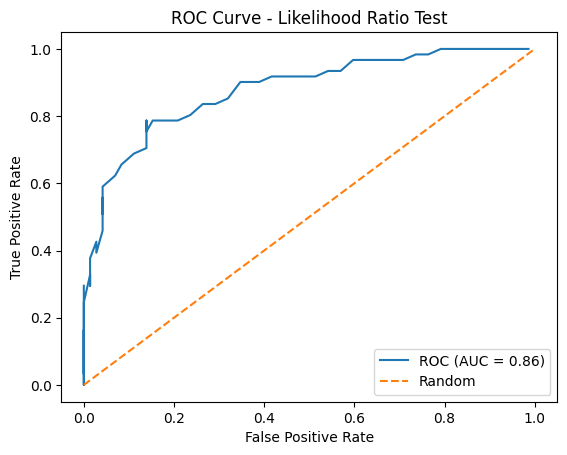

In [61]:
plt.figure()

plt.plot(
    FPR_sorted,
    TPR_sorted,
    label=f"ROC (AUC = {auc:.2f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Likelihood Ratio Test")
plt.legend()

plt.show()

### Threshold vs Detection Rate Plot

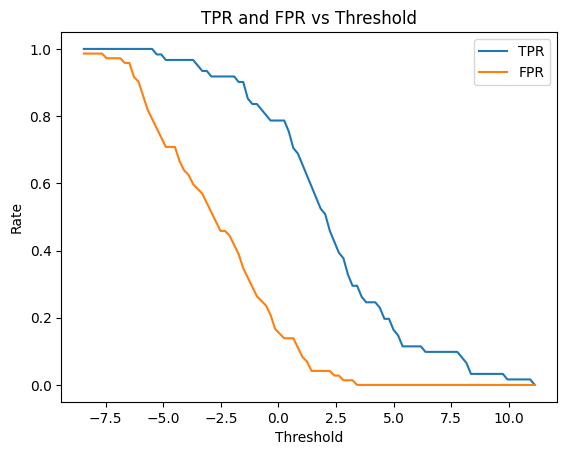

In [62]:
plt.figure()

plt.plot(thresholds, TPR, label="TPR")

plt.plot(thresholds, FPR, label="FPR")

plt.xlabel("Threshold")

plt.ylabel("Rate")

plt.title("TPR and FPR vs Threshold")

plt.legend()

plt.show()